Using LIANA ligand-receptor databases to construct the ligand-target
model
================

Following the [Construction of NicheNet’s ligand-target
model](model_construction.ipynb) notebook, we will now demonstrate how to
use ligand-receptor reactions from LIANA to build the ligand-target
model. LIANA is a framework that combines both resources and
computational tools for ligand-receptor cell-cell communication
inference (Dimitrov et al., 2022). As the NicheNet prior model is built
by integrating ligand-receptor, signaling, and gene regulatory
databases, each part can be replaced with external data sources. We will
show how the first part, the ligand-receptor database, can be replaced
with those from LIANA, and how to run the model afterward.

**Important**: Since LIANA also offers functions to calculate
ligand-receptor interactions of interest, it is also possible to use
them to select which ligands are of interest to do the ligand activity
analysis. 

In [1]:
from nichenetpy.utils import (
    read_csv_cols,
    read_csv_rows,
    decomplexify
)
from nichenetpy.model_construction import (
    construct_weighted_networks,
    construct_ligand_target_matrix,
    apply_hub_correction
)
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.extraction import get_expressed_genes
from nichenetpy.ann_utils import subset_ann
from nichenetpy.metrics import group_metrics
from nichenetpy.visualization import heatmap_1d
from nichenetpy.wrappers import (
    run_nichenet,
    create_ligand_activity_heatmap
)

from itertools import repeat
from liana.resource import (
    show_resources,
    select_resource
)

import os
import requests
import pandas as pd
import re
import anndata
import matplotlib.pyplot as plt
import pickle
import session_info

In [ ]:
human_network_path = os.path.normpath("./tutorial_files/model_construction/human")
if not os.path.exists(human_network_path):
    os.makedirs(human_network_path)
for filename in (
    "gr_human.csv",
    "lr_network_human.csv",
    "lr_sig_human.csv",
    "source_weights.csv"
):
    file_path = os.path.join(human_network_path, filename)
    if not os.path.exists(file_path):
        resource = requests.get(f"https://zenodo.org/records/15168364/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(resource.content)
mouse_network_path = os.path.normpath("./tutorial_files/model_construction/mouse")
if not os.path.exists(mouse_network_path):
    os.makedirs(mouse_network_path)
for filename in (
    "gr_mouse.csv",
    "lr_network_mouse.csv",
    "lr_sig_mouse.csv",
    "optimized_source_weights.csv"
):
    file_path = os.path.join(mouse_network_path, filename)
    if not os.path.exists(file_path):
        resource = requests.get(f"https://zenodo.org/records/15168364/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(resource.content)
data_path = os.path.normpath("./tutorial_files/AnnData")
if not os.path.exists(data_path):
    os.makedirs(data_path)
filename = "annData3531889.h5"
file_path = os.path.join(data_path, filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/15574665/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)
model_path = os.path.normpath("./tutorial_files/model/mouse")
filename = "nichenet_mouse.pkl"
file_path = os.path.join("./tutorial_files", filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/15584943/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

In [3]:
gr_network_human = pd.DataFrame(read_csv_cols(os.path.join(human_network_path, "gr_human.csv")))
lr_network_human = pd.DataFrame(read_csv_cols(os.path.join(human_network_path, "lr_network_human.csv")))
sig_network_human = pd.DataFrame(read_csv_cols(os.path.join(human_network_path, "lr_sig_human.csv")))
gr_network_mouse = pd.DataFrame(read_csv_cols(os.path.join(mouse_network_path, "gr_mouse.csv")))
lr_network_mouse = pd.DataFrame(read_csv_cols(os.path.join(mouse_network_path, "lr_network_mouse.csv")))
sig_network_mouse = pd.DataFrame(read_csv_cols(os.path.join(mouse_network_path, "lr_sig_mouse.csv")))
source_weights = list(zip(*read_csv_rows("./tutorial_files/model_construction/human/source_weights.csv")[1]))
source_weights = dict(zip(source_weights[0], [float(e) for e in source_weights[1]]))
optimized_source_weights = list(zip(*read_csv_rows("./tutorial_files/model_construction/mouse/optimized_source_weights.csv")[1]))
optimized_source_weights = dict(zip(optimized_source_weights[0], [float(e) for e in optimized_source_weights[1]]))

To check which resources are present in LIANA, we can use the show_resources() function. These are then accessed via select_resource().

In [4]:
show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

Next, we will calculate how much overlap there is between the ligands and receptors in the LIANA and NicheNet databases. If the overlap between LIANA receptors and NicheNet signaling network is too low, the integration will probably not work very well. 

In [5]:
mouse_re = r".*mouse.*"
n_ligands = []
n_receptors = []
n_ligands_overlap = []
n_receptors_overlap_lr = []
n_receptors_overlap_sig = []
for resource in show_resources():
    db = decomplexify(select_resource(resource))
    lr_network, sig_network = (
        (lr_network_human, sig_network_human)
        if re.match(mouse_re, resource) is None
        else (lr_network_mouse, sig_network_mouse)
    )
    n_ligands.append(len(set(db["ligand"])))
    n_receptors.append(len(set(db["receptor"])))
    n_ligands_overlap.append(len(set(db["ligand"]).intersection(lr_network["from"])))
    n_receptors_overlap_lr.append(len(set(db["receptor"]).intersection(lr_network["to"])))
    n_receptors_overlap_sig.append(len(set(db["receptor"]).intersection(sig_network["from"])))
overlap_df = pd.DataFrame({
    "n_ligands": n_ligands,
    "n_receptors": n_receptors,
    "n_ligands_overlap": n_ligands_overlap,
    "n_receptors_overlap_lr": n_receptors_overlap_lr,
    "n_receptors_overlap_sig": n_receptors_overlap_sig
}, index=show_resources())
overlap_df["frac_ligands_overlap"] = overlap_df["n_ligands_overlap"] / overlap_df["n_ligands"]
overlap_df["frac_ligands_overlap_lr"] = overlap_df["n_receptors_overlap_lr"] / overlap_df["n_receptors"]
overlap_df["frac_ligands_overlap_sig"] = overlap_df["n_receptors_overlap_sig"] / overlap_df["n_receptors"]
overlap_df

,n_ligands,n_receptors,n_ligands_overlap,n_receptors_overlap_lr,n_receptors_overlap_sig,frac_ligands_overlap,frac_ligands_overlap_lr,frac_ligands_overlap_sig
baccin2019,650,612,550,535,611,0.846154,0.874183,0.998366
cellcall,276,195,272,193,195,0.985507,0.989744,1.000000
cellchatdb,531,450,515,430,447,0.969868,0.955556,0.993333
cellinker,1216,1010,879,817,1003,0.722862,0.808911,0.993069
cellphonedb,500,461,479,415,458,0.958000,0.900217,0.993492
celltalkdb,812,780,741,683,776,0.912562,0.875641,0.994872
connectomedb2020,813,681,768,640,678,0.944649,0.939794,0.995595
consensus,1032,934,923,794,927,0.894380,0.850107,0.992505
embrace,462,473,435,436,473,0.941558,0.921776,1.000000
guide2pharma,293,243,289,242,243,0.986348,0.995885,1.000000


On average, ~90% of the ligands and receptors of LIANA databases are in the NicheNet LR network (frac_ligands_overlap, frac_receptors_overlap_lr), and almost all of the receptors in LIANA databases are present in the NicheNet signaling network (frac_receptors_overlap_sig). When using the “Consensus” database of LIANA, there are ~100 ligands that are not present in NicheNet; in contrast, there are 303 ligands in NicheNet that are not present in the LIANA consensus database.

To build the ligand-target model, we can use a very similar code to the Construction of NicheNet’s ligand-target model vignette. Users can choose between replacing the NicheNet LR database entirely with LIANA’s (replace_nichenet_lr = TRUE), or just adding the LIANA database as an additional data source, which may contain a lot of redundant information.

In [6]:
replace_nichenet_lr = True
liana_db = decomplexify(select_resource("Consensus"))
liana_db.rename(columns={
    "ligand": "from",
    "receptor": "to"
}, inplace=True)
liana_db["source"] = list(repeat("liana", len(liana_db)))
if not replace_nichenet_lr:
    liana_db = pd.concat((lr_network_human, liana_db))
source_weights["liana"] = 1
weighted_networks = construct_weighted_networks(
    liana_db,
    sig_network_human,
    gr_network_human,
    source_weights
)
weighted_networks["lr_sig"] = apply_hub_correction(weighted_networks["lr_sig"], hub=0.115)
weighted_networks["gr"] = apply_hub_correction(weighted_networks["gr"], hub=0.0803)
ligands = [["TNF"], ["TNF", "IL6"]]
predictor = LigandActivityPredictor(
    *construct_ligand_target_matrix(
        weighted_networks,
        lr_network,
        ligands,
        damping_factor=0.789,
        ltf_cutoff=0.926
    )
)

### Running NicheNet on the LIANA ligand-target model
In this section compare the results between using the LIANA LR network and NicheNet one in a typical NicheNet analysis. As this is mouse scRNA-seq data, we will build the model using mouse networks (“mouseconsensus” resource in LIANA). Furthermore, instead of using the same source weights for all data sources as in the previous section, we will use the optimized data source weights. Here, we will use the same data source weight for the LIANA model as the one that was computed for the NicheNet LR network. This may not be the optimal weight, but it requires a lot of runtime to notebook this parameter (see Parameter optimization vignette for more information).

In [7]:
ann = anndata.io.read_h5ad(os.path.join(data_path, "annData3531889.h5"))
ann.var_names = ann.var["gene"]
mouse_alias_info.alias_to_symbol(ann)
lr_network_liana = decomplexify(select_resource("mouseconsensus"))
lr_network_liana.rename(columns={
    "ligand": "from",
    "receptor": "to"
}, inplace=True)
receiver = "CD8 T"
expressed_genes_receiver = set(get_expressed_genes(receiver, ann, 0.1))
sender_celltypes = ("CD4 T", "Treg", "Mono", "NK", "B", "DC")
list_expressed_genes_sender = [get_expressed_genes(ct, ann, pct=0.1) for ct in sender_celltypes]
expressed_genes_sender = set(e for l in list_expressed_genes_sender for e in l)
ann_receiver = subset_ann(
    ann,
    val=receiver,
    val_col="celltype"
)
group_metrics(
    ann_receiver,
    groupby="aggregate",
    layer="data",
    min_pct=0.1,
    min_abs_lfc=0.25
)
DE_table = ann_receiver.uns["group_metrics"]
geneset = set(
    DE_table[
        (DE_table["aggregate"] == "LCMV") &
        (DE_table["pval_adj"] <= 0.05)
    ]["gene"]
)
ligands = set(lr_network_liana["from"])
receptors = set(lr_network_liana["to"])
expressed_ligands = ligands.intersection(expressed_genes_sender)
expressed_receptors = receptors.intersection(expressed_genes_receiver)
potential_ligands = set(lr_network_liana[[
    (fr in expressed_ligands) & (to in expressed_receptors)
    for fr, to in zip(lr_network_liana["from"], lr_network_liana["to"])
]]["from"])
optimized_source_weights["liana"] = optimized_source_weights["nichenet_verschueren"]
weighted_networks_liana = construct_weighted_networks(
    lr_network_liana,
    sig_network_mouse,
    gr_network_mouse,
    optimized_source_weights
)
weighted_networks_liana["lr_sig"] = apply_hub_correction(weighted_networks_liana["lr_sig"], hub=0.115)
weighted_networks_liana["gr"] = apply_hub_correction(weighted_networks_liana["gr"], hub=0.0803)
predictor_liana = LigandActivityPredictor(
    *construct_ligand_target_matrix(
        weighted_networks_liana,
        lr_network_liana,
        potential_ligands,
        damping_factor=0.789,
        ltf_cutoff=0.926
    )
)
geneset.intersection_update(predictor_liana.get_genes())
background_expressed_genes = expressed_genes_receiver.intersection(predictor_liana.get_genes())
ligand_activities = sorted(
    predictor_liana.predict_ligand_activities(
        geneset,
        background_expressed_genes,
        potential_ligands
    ).items(),
    key=lambda x : (-x[1]["aupr_corrected"], x[0])
)

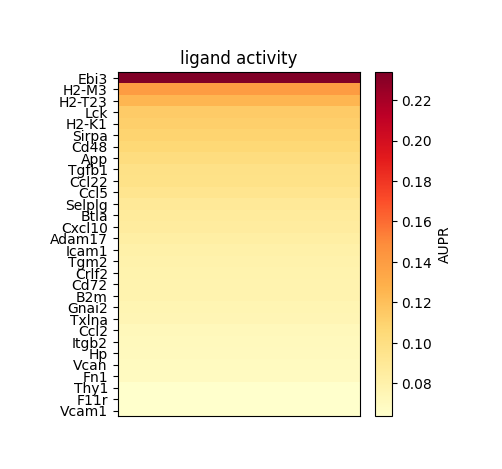

In [8]:
ligands, metrics = zip(*ligand_activities[:30])
fig, ax = heatmap_1d(
    [e["aupr_corrected"] for e in metrics],
    labels=ligands,
    title="ligand activity",
    cbar_label="AUPR",
    cmap="YlOrRd",
    figsize=(4, 4)
)
ax.invert_yaxis()
plt.show()

#### Compare results with NicheNet ligand-target model

Run NicheNet using the wrapper function.

In [9]:
with open("./tutorial_files/nichenet_mouse.pkl", "rb") as file:
    model = pickle.loads(file.read())
predictor = model["predictor"]
lr_network = model["lr_network"]
lr_sig = model["lr_sig"]
res = run_nichenet(
    ann,
    predictor,
    lr_network,
    "CD8 T",
    "aggregate",
    "LCMV",
    "SS",
    sender_celltypes=sender_celltypes,
    lr_sig=lr_sig
)

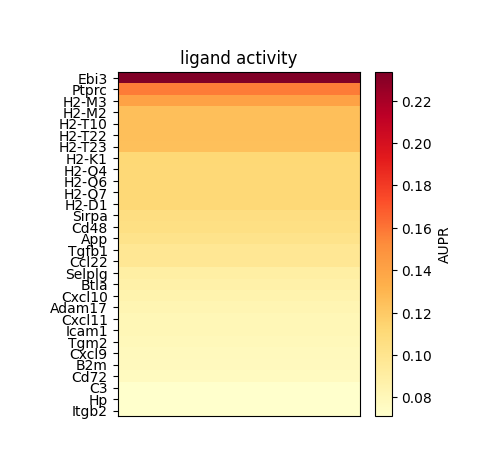

In [10]:
create_ligand_activity_heatmap(
    res["ligand_activities_sorted_focused"][:30],
    figsize=(4, 4)
)

Compare the results between LIANA and NicheNet. Here we see that half of the top 20 ligands between the two are the same.

In [11]:
len(
    {e[0] for e in ligand_activities[:20]}.intersection(
        {e[0] for e in res["ligand_activities_sorted_focused"][:20]}
    )
)/20

0.6

In [12]:
session_info.show()

## References

Dimitrov, D., Türei, D., Garrido-Rodriguez M., Burmedi P.L., Nagai,
J.S., Boys, C., Flores, R.O.R., Kim, H., Szalai, B., Costa, I.G.,
Valdeolivas, A., Dugourd, A. and Saez-Rodriguez, J. Comparison of
methods and resources for cell-cell communication inference from
single-cell RNA-Seq data. Nat Commun 13, 3224 (2022).
<https://doi.org/10.1038/s41467-022-30755-0>